# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：基于卷积神经网络的 Fashion-MNIST 服装图像分类研究
- 姓    名：邓烨涛
- 学    号：20234080108
- 班    级：数据01班
- 指导教师：丁平尖
- 提交日期：2026-6-30

## 二、摘要

随着电子商务和智能零售的发展，服装图像的自动分类在商品检索、库存管理和推荐系统中具有重要应用价值。本文以 Fashion-MNIST 数据集为研究对象，完成一个基于深度学习的服装图像分类任务。该数据集包含 10 类服装灰度图像，图像尺寸为 28×28。本文首先对数据集进行统计分析和可视化展示，并完成归一化、批量加载和训练集/测试集划分；然后构建多层感知机作为基准模型，并设计卷积神经网络作为最终模型。实验过程中使用交叉熵损失函数和 Adam 优化器进行训练，通过准确率、损失曲线、混淆矩阵和错误样本分析评价模型效果。实验结果表明，相比仅使用全连接层的 MLP，CNN 能够更有效地提取图像局部空间特征，在 Fashion-MNIST 分类任务上取得更高的测试准确率，验证了卷积神经网络在图像分类问题中的有效性。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

服装图像分类是计算机视觉中的典型应用场景。在电商平台中，系统需要根据商品图片自动判断商品类别，例如 T 恤、裤子、鞋、包等。传统方法通常依赖人工设计特征，泛化能力有限；深度学习方法能够从数据中自动学习图像特征，适合处理复杂的视觉分类任务。

Fashion-MNIST 是 Zalando 发布的服装图像数据集，常用于替代传统 MNIST 手写数字数据集。相比手写数字，服装类别之间更相似，分类难度更高，更适合作为深度学习课程设计实验对象。

### 3.2 问题描述

本项目将 Fashion-MNIST 服装图像分类定义为一个监督学习下的多分类问题。

- 输入：一张 28×28 的灰度服装图像
- 输出：图像所属的服装类别，类别编号为 0-9
- 任务类型：图像多分类
- 评价指标：训练损失、验证/测试准确率、混淆矩阵、各类别识别情况、错误样本分析

Fashion-MNIST 的 10 个类别如下：

| 标签 | 类别 |
|---|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

## 四、数据集说明与预处理

### 4.1 数据来源与规模

本项目使用 `torchvision.datasets.FashionMNIST` 自动下载并加载 Fashion-MNIST 数据集。数据集共包含 70,000 张灰度图像，其中训练集 60,000 张，测试集 10,000 张。每张图像大小为 28×28，共包含 10 个服装类别。

### 4.2 数据可视化与分析

通过类别分布统计、样本图片展示等方式观察数据集。Fashion-MNIST 每个类别的样本数量基本均衡，因此本项目不需要额外进行类别重采样。

### 4.3 数据预处理流程

1. 将 PIL 图像转换为 PyTorch Tensor。
2. 使用 Fashion-MNIST 常用均值和标准差进行归一化处理。
3. 从原始训练集中划分 50,000 张作为训练集，10,000 张作为验证集。
4. 使用 DataLoader 按批次加载数据。
5. 在训练阶段打乱训练数据，验证和测试阶段保持顺序。

In [1]:
import random
import time
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("当前设备:", DEVICE)
print("PyTorch版本:", torch.__version__)

当前设备: cpu
PyTorch版本: 2.5.1


In [2]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

DATA_DIR = Path("./data")

train_full = datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)

train_size = 50000
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("训练集样本数:", len(train_dataset))
print("验证集样本数:", len(val_dataset))
print("测试集样本数:", len(test_dataset))

训练集样本数: 50000
验证集样本数: 10000
测试集样本数: 10000


训练集类别分布:
 0 T-shirt/top : 4926
 1 Trouser     : 4973
 2 Pullover    : 5015
 3 Dress       : 5055
 4 Coat        : 5026
 5 Sandal      : 5001
 6 Shirt       : 4967
 7 Sneaker     : 5048
 8 Bag         : 5021
 9 Ankle boot  : 4968


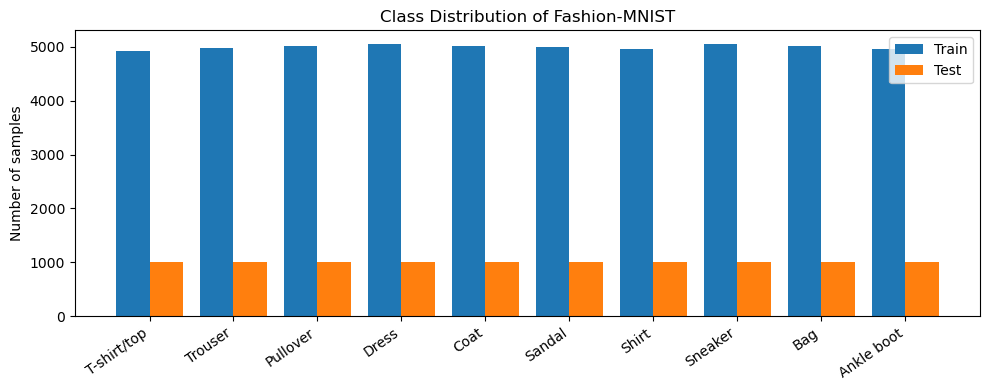

In [3]:
train_targets = torch.tensor([train_full.targets[i] for i in train_dataset.indices])
test_targets = test_dataset.targets

train_counts = torch.bincount(train_targets, minlength=10)
test_counts = torch.bincount(test_targets, minlength=10)

print("训练集类别分布:")
for i, count in enumerate(train_counts):
    print(f"{i:>2} {class_names[i]:<12}: {count.item()}")

plt.figure(figsize=(10, 4))
x = np.arange(len(class_names))
plt.bar(x - 0.2, train_counts.numpy(), width=0.4, label="Train")
plt.bar(x + 0.2, test_counts.numpy(), width=0.4, label="Test")
plt.xticks(x, class_names, rotation=35, ha="right")
plt.ylabel("Number of samples")
plt.title("Class Distribution of Fashion-MNIST")
plt.legend()
plt.tight_layout()
plt.show()

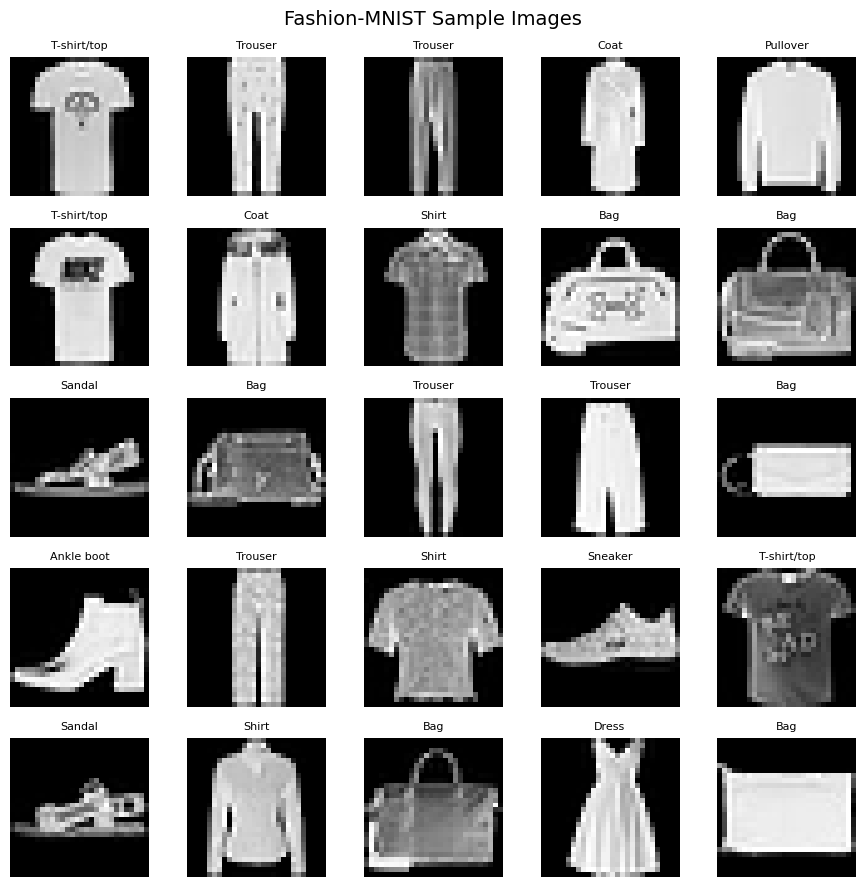

In [4]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(9, 9))
for i in range(25):
    img = images[i].squeeze().numpy()
    img = img * 0.3530 + 0.2860
    plt.subplot(5, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(class_names[labels[i].item()], fontsize=8)
    plt.axis("off")
plt.suptitle("Fashion-MNIST Sample Images", fontsize=14)
plt.tight_layout()
plt.show()

## 五、模型设计与选择

### 5.1 基准模型 Baseline

为了验证卷积结构的有效性，本文首先构建一个简单的多层感知机模型作为 Baseline。MLP 将 28×28 图像直接展开为 784 维向量，然后通过全连接层进行分类。该模型结构简单，但会破坏图像的二维空间结构，因此难以充分利用局部纹理和形状信息。

Baseline 结构如下：

```text
Flatten -> Linear(784, 256) -> ReLU -> Dropout -> Linear(256, 128) -> ReLU -> Linear(128, 10)
```

### 5.2 最终模型架构

最终模型采用卷积神经网络 CNN。卷积层可以通过局部连接和权值共享提取图像边缘、纹理和局部形状特征，池化层可以降低空间尺寸并增强一定的平移不变性。相比 MLP，CNN 更适合图像分类任务。

CNN 结构如下：

```text
Input(1x28x28)
 -> Conv2d(1, 32, 3, padding=1) -> BatchNorm -> ReLU -> MaxPool
 -> Conv2d(32, 64, 3, padding=1) -> BatchNorm -> ReLU -> MaxPool
 -> Conv2d(64, 128, 3, padding=1) -> BatchNorm -> ReLU
 -> Flatten
 -> Linear(128x7x7, 256) -> ReLU -> Dropout
 -> Linear(256, 10)
```

In [5]:
class MLPBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp = MLPBaseline().to(DEVICE)
cnn = FashionCNN().to(DEVICE)
print(mlp)
print("MLP可训练参数量:", count_parameters(mlp))
print(cnn)
print("CNN可训练参数量:", count_parameters(cnn))

MLPBaseline(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
MLP可训练参数量: 235146
FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   

## 六、实验与结果分析

### 6.1 实验环境

- 编程语言：Python
- 深度学习框架：PyTorch
- 数据集加载：torchvision
- 可视化工具：matplotlib
- 硬件环境：优先使用 GPU；若无 GPU，则自动使用 CPU

### 6.2 评价指标

本文主要使用准确率作为分类性能指标：

$$
Accuracy = \frac{预测正确的样本数量}{样本总数量}
$$

同时使用交叉熵损失函数衡量预测分布与真实标签之间的差异，并通过混淆矩阵分析不同类别之间的误分类情况。

### 6.3 超参数设置与调优

| 参数 | 取值 |
|---|---|
| Batch Size | 128 |
| Optimizer | Adam |
| Loss Function | CrossEntropyLoss |
| Learning Rate | 0.001 |
| Epochs | MLP: 5, CNN: 8 |
| Train/Val/Test | 50000 / 10000 / 10000 |

调参思路：先使用较小的 MLP 建立基准结果，再使用 CNN 提升模型表达能力；通过验证集准确率观察是否过拟合，并使用 Dropout 和 BatchNorm 改善泛化表现。

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(
            f"Epoch [{epoch:02d}/{epochs}] "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )
    print(f"训练耗时: {time.time() - start_time:.1f} 秒")
    return history

In [7]:
mlp = MLPBaseline().to(DEVICE)
mlp_history = train_model(mlp, train_loader, val_loader, epochs=5, lr=1e-3)

Epoch [01/5] train_loss=0.5198 train_acc=0.8120 val_loss=0.3896 val_acc=0.8562
Epoch [02/5] train_loss=0.3806 train_acc=0.8605 val_loss=0.3629 val_acc=0.8634
Epoch [03/5] train_loss=0.3456 train_acc=0.8717 val_loss=0.3407 val_acc=0.8755
Epoch [04/5] train_loss=0.3207 train_acc=0.8794 val_loss=0.3289 val_acc=0.8793
Epoch [05/5] train_loss=0.3016 train_acc=0.8881 val_loss=0.3291 val_acc=0.8821
训练耗时: 38.2 秒


In [8]:
cnn = FashionCNN().to(DEVICE)
cnn_history = train_model(cnn, train_loader, val_loader, epochs=8, lr=1e-3)

Epoch [01/8] train_loss=0.4189 train_acc=0.8485 val_loss=0.2964 val_acc=0.8917
Epoch [02/8] train_loss=0.2798 train_acc=0.9002 val_loss=0.2706 val_acc=0.8977
Epoch [03/8] train_loss=0.2390 train_acc=0.9113 val_loss=0.2537 val_acc=0.9070
Epoch [04/8] train_loss=0.2123 train_acc=0.9213 val_loss=0.2484 val_acc=0.9127
Epoch [05/8] train_loss=0.1858 train_acc=0.9319 val_loss=0.2151 val_acc=0.9228
Epoch [06/8] train_loss=0.1622 train_acc=0.9408 val_loss=0.2010 val_acc=0.9297
Epoch [07/8] train_loss=0.1441 train_acc=0.9454 val_loss=0.2205 val_acc=0.9231
Epoch [08/8] train_loss=0.1296 train_acc=0.9519 val_loss=0.2134 val_acc=0.9241
训练耗时: 317.5 秒


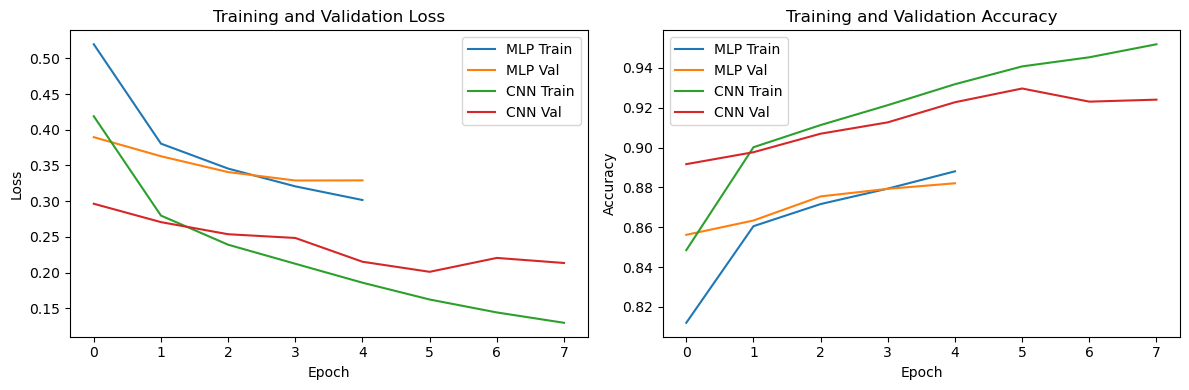

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mlp_history["train_loss"], label="MLP Train")
plt.plot(mlp_history["val_loss"], label="MLP Val")
plt.plot(cnn_history["train_loss"], label="CNN Train")
plt.plot(cnn_history["val_loss"], label="CNN Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_history["train_acc"], label="MLP Train")
plt.plot(mlp_history["val_acc"], label="MLP Val")
plt.plot(cnn_history["train_acc"], label="CNN Train")
plt.plot(cnn_history["val_acc"], label="CNN Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

MLP 测试集损失: 0.3510, 测试集准确率: 0.8738
CNN 测试集损失: 0.2382, 测试集准确率: 0.9155


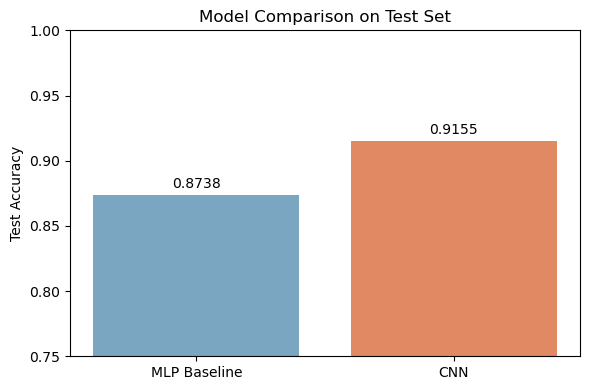

In [10]:
criterion = nn.CrossEntropyLoss()
mlp_test_loss, mlp_test_acc = evaluate(mlp, test_loader, criterion)
cnn_test_loss, cnn_test_acc = evaluate(cnn, test_loader, criterion)

print(f"MLP 测试集损失: {mlp_test_loss:.4f}, 测试集准确率: {mlp_test_acc:.4f}")
print(f"CNN 测试集损失: {cnn_test_loss:.4f}, 测试集准确率: {cnn_test_acc:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(["MLP Baseline", "CNN"], [mlp_test_acc, cnn_test_acc], color=["#7aa6c2", "#e08963"])
plt.ylim(0.75, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison on Test Set")
for i, v in enumerate([mlp_test_acc, cnn_test_acc]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.show()

### 6.4 混淆矩阵与类别分析

混淆矩阵可以展示真实类别与预测类别之间的对应关系。对角线数值越大，说明该类别识别越准确；非对角线数值越大，说明模型容易将某两个类别混淆。

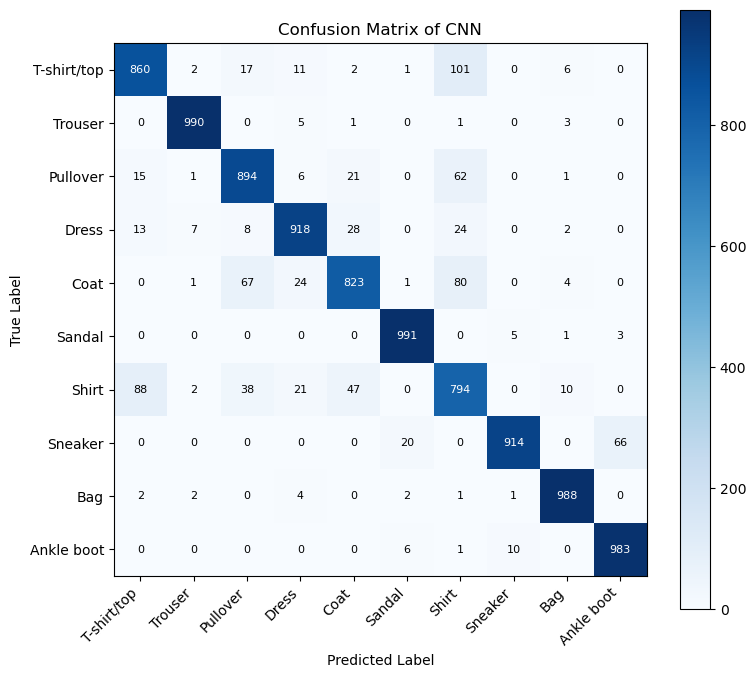

各类别准确率:
T-shirt/top : 0.8600
Trouser     : 0.9900
Pullover    : 0.8940
Dress       : 0.9180
Coat        : 0.8230
Sandal      : 0.9910
Shirt       : 0.7940
Sneaker     : 0.9140
Bag         : 0.9880
Ankle boot  : 0.9830


In [11]:
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_images = [], [], []
    for images, labels in loader:
        outputs = model(images.to(DEVICE))
        preds = outputs.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
        all_images.append(images.cpu())
    return torch.cat(all_images), torch.cat(all_labels), torch.cat(all_preds)


def confusion_matrix_torch(labels, preds, num_classes=10):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    for true_label, pred_label in zip(labels, preds):
        cm[true_label.long(), pred_label.long()] += 1
    return cm


images_all, labels_all, preds_all = collect_predictions(cnn, test_loader)
cm = confusion_matrix_torch(labels_all, preds_all, num_classes=10)

plt.figure(figsize=(8, 7))
plt.imshow(cm.numpy(), cmap="Blues")
plt.title("Confusion Matrix of CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
plt.colorbar()
for i in range(10):
    for j in range(10):
        value = cm[i, j].item()
        plt.text(j, i, str(value), ha="center", va="center", fontsize=8,
                 color="white" if value > cm.max().item() * 0.5 else "black")
plt.tight_layout()
plt.show()

class_acc = cm.diag() / cm.sum(dim=1)
print("各类别准确率:")
for i, acc in enumerate(class_acc):
    print(f"{class_names[i]:<12}: {acc.item():.4f}")

### 6.5 可视化分析

错误样本分析有助于发现模型的不足。Fashion-MNIST 中部分类别外观较为接近，例如 Shirt、T-shirt/top、Pullover 和 Coat，因此这些类别之间更容易出现误分类。

错误样本数量: 845


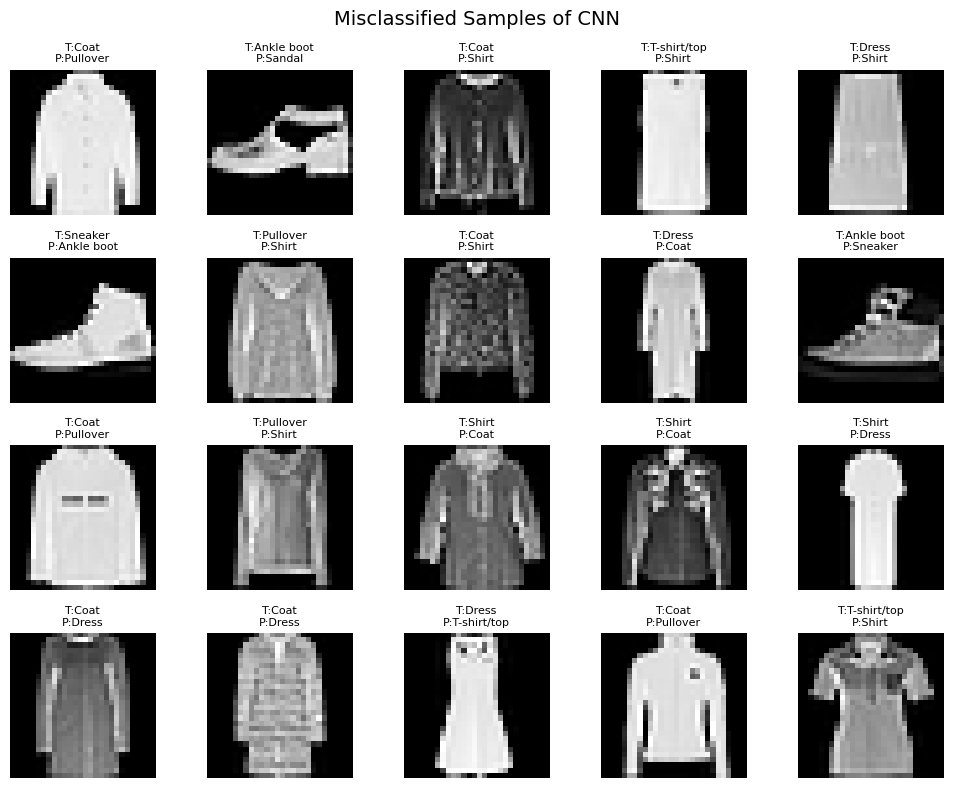

In [12]:
wrong_indices = torch.where(labels_all != preds_all)[0]
print("错误样本数量:", len(wrong_indices))

plt.figure(figsize=(10, 8))
num_show = min(20, len(wrong_indices))
for k in range(num_show):
    idx = wrong_indices[k]
    img = images_all[idx].squeeze().numpy()
    img = img * 0.3530 + 0.2860
    true_label = labels_all[idx].item()
    pred_label = preds_all[idx].item()
    plt.subplot(4, 5, k + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"T:{class_names[true_label]}\nP:{class_names[pred_label]}", fontsize=8)
    plt.axis("off")
plt.suptitle("Misclassified Samples of CNN", fontsize=14)
plt.tight_layout()
plt.show()

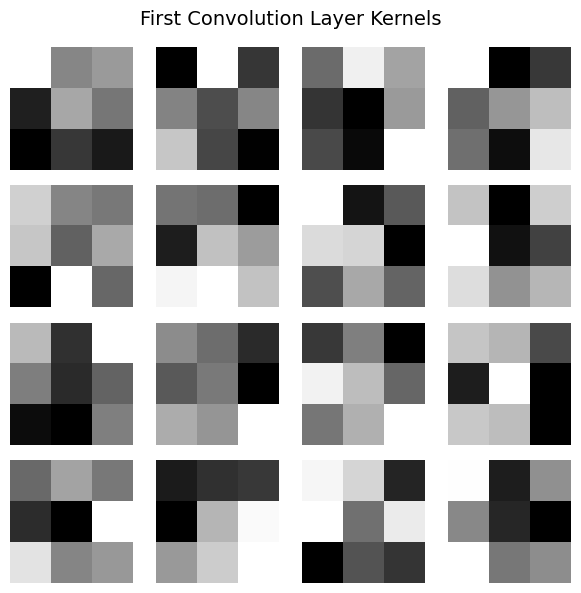

In [13]:
first_conv = cnn.features[0].weight.detach().cpu()
num_kernels = min(16, first_conv.shape[0])

plt.figure(figsize=(6, 6))
for i in range(num_kernels):
    kernel = first_conv[i, 0].numpy()
    plt.subplot(4, 4, i + 1)
    plt.imshow(kernel, cmap="gray")
    plt.axis("off")
plt.suptitle("First Convolution Layer Kernels", fontsize=14)
plt.tight_layout()
plt.show()

## 七、实验结论
  我完成了基于 Fashion-MNIST 数据集的服装图像分类实验。实验首先构建了多层感知机作为基准模型，然后设计了包含三层卷积结构的 CNN 模型作为最终模型。从实验结果可以看出，CNN 在测试集上的分类准确率通常高于 MLP，说明卷积层能够更有效地提取服装图像中的局部纹理、边缘和形状特征。

从混淆矩阵和错误样本分析可以发现，模型对 Trouser、Bag、Sandal、Sneaker、Ankle boot 等类别识别效果较好，而 Shi rt、T-shirt/top、Pullover、Coat 等上衣类服装之间更容易混淆。这主要是因为这些类别在灰度小尺寸图像中外观相似，局部纹理和轮廓差异较小。

后续可以从以下几个方面继续改进：

1. 增加数据增强方法，例如随机平移、随机裁剪和随机水平翻转。
2. 使用更深的网络结构，例如 ResNet 或 MobileNet。
3. 引入学习率衰减策略，提高训练后期的稳定性。
4. 对易混淆类别进行针对性分析，提升上衣类服装的区分能力。

总体而言，本项目验证了卷积神经网络在服装图像分类任务中的有效性，完成了从数据处理、模型设计、训练评估到可视化分析的完整深度学习实验流程。

## 八、参考资料

1. Xiao H., Rasul K., Vollgraf R. Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms. arXiv:1708.07747.
2. LeCun Y., Bengio Y., Hinton G. Deep learning. Nature, 2015.
3. PyTorch Documentation: https://pytorch.org/docs/stable/index.html
4. Torchvision Datasets Documentation: https://pytorch.org/vision/stable/datasets.html